In [ ]:
!pip install kagglehub[pandas-datasets]

In [1]:
!pip install s3fs
import pandas as pd
import s3fs

fs = s3fs.S3FileSystem(anon=True)

bucket_path = 'cse-cic-ids2018/Processed Traffic Data for ML Algorithms/'

# List all CSV files in the directory
# Filter to ensure we only get files ending in .csv
files = [f"s3://{file}" for file in fs.ls(bucket_path) if file.endswith('.csv')]
files = files[:5] if len(files) > 5 else files
print(f"Found {files} files. Starting merge...")

# Load and combine (using a list comprehension for efficiency)
df_list = [pd.read_csv(f, storage_options={'anon': True}, low_memory=True) for f in files]
combined_df = pd.concat(df_list, ignore_index=True)

# Basic cleaning: remove rows that repeat the header
combined_df = combined_df[combined_df['Label'] != 'Label']
labels = combined_df['Label']
features = combined_df.drop(columns=['Label'])

# 4. Convert all features to float32
# 'coerce' turns errors (like 'Infinity' or random text) into NaN
features = features.apply(pd.to_numeric, errors='coerce', downcast='float')
print(f"Total Rows: {len(combined_df)}")
print(f"Total Features: {len(combined_df.columns)}\nFeature List:\n{combined_df.columns}")
print(combined_df['Label'].value_counts())

Found ['s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv', 's3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-16-02-2018_TrafficForML_CICFlowMeter.csv', 's3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-23-02-2018_TrafficForML_CICFlowMeter.csv', 's3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv', 's3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv'] files. Starting merge...


C:\Users\3acktrack\AppData\Local\Temp\ipykernel_6656\3061585825.py:16: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f, storage_options={'anon': True}, low_memory=True) for f in files]
C:\Users\3acktrack\AppData\Local\Temp\ipykernel_6656\3061585825.py:16: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(f, storage_options={'anon': True}, low_memory=True) for f in files]


Total Rows: 11425572
Total Features: 84
Feature List:
Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', '

In [3]:
import numpy as np
#Attack type breakdown
features.replace([np.inf, -np.inf], np.nan, inplace=True)
features.dropna(inplace=True)

# Convert numerical columns from object to float (S3 loads them as objects if headers repeat)
#features.iloc[:, :-1] = combined_df.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')
#features.dropna(inplace=True)




KeyboardInterrupt: 

In [3]:
#FeatureEngineering
import numpy as np
df = features
df.head()
df['BytePerPacket'] = (df['TotLen Fwd Pkts'] + df['TotLen Bwd Pkts']) / (df['Tot Fwd Pkts'] + df['Tot Bwd Pkts'])
df['Dst Port'] = df['Dst Port']/100000
for column in df.columns:
  if column in ['Dst Port', 'Label']:
    continue
  colN = column.lower()
  if colN.endswith('min') or colN.endswith('max') or colN.endswith('std') or colN.endswith('mean'):
    df.drop(column, axis=1, inplace=True)
    continue
  df[column] = df[column].replace([np.inf, -np.inf], np.nan)
  df = df.fillna(0.0)
  mean = df[column].mean()
  std = df[column].std()
  if std != 0:
    df[column] = (df[column]-mean)/std
  else:
    df[column] = (df[column]-mean)/mean


In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import label_binarize
#from sklearn.preprocessing import LabelEncoder
#le = LabelEncoder()  -> binary

Y = labels
n_classes = len(set(Y))
#Y = label_binarize(Y, classes=[*range(n_classes)])
#Y = le.fit_transform(Y)
#Y[:5]
#df.drop('Label', axis=1, inplace=True)
print (df.columns)
X = df
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,        # Usually 20% or 30% for the test set
    random_state=42,      # Keeps results consistent
    stratify=Y            # <--- THIS creates the comparable distribution
)
#smote = SMOTE(random_state=42)
#X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow Byts/s',
       'Flow Pkts/s', 'Fwd IAT Tot', 'Bwd IAT Tot', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len',
       'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Var',
       'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
       'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt',
       'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
       'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg',
       'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg',
       'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
       'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
       'Fwd Act Data Pkts', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP',
       'BytePerPacket'],
      dtype='object')


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.multiclass import OneVsRestClassifier
#del df
#del combined_df
model_weighted = RandomForestClassifier(class_weight="balanced", random_state=42)
model_weighted.fit(X_train, y_train)
print("Baseline (Weighted) Results:")
y_pred = model_weighted.predict(X_test)

threshold = 0.95

#y_pred_custom = (y_probs >= threshold).astype(int)
print(classification_report(y_test, y_pred))

"""
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_resampled, y_resampled)

print("\nSMOTE Results:")
y_probs = model_weighted.predict_proba(X_test)[:, 1]

threshold = 0.95

y_pred_custom = (y_probs >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))
"""

Baseline (Weighted) Results:
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   1973552
                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.27      0.76      0.39        72
        Brute Force -XSS       0.85      0.93      0.89        30
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115238
        DoS attacks-Hulk       1.00      1.00      1.00     92383
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     27978
           Infilteration       0.25      0.42      0.31     18613
           SQL Injection       1.00      0.55      0.71        11

                accuracy                           0.98   2285115
               macro avg       0.82      0.85      0.81   2285115
            weighted avg       0.99      0.98      0.99   2285115



'\nmodel_smote = RandomForestClassifier(random_state=42)\nmodel_smote.fit(X_resampled, y_resampled)\n\nprint("\nSMOTE Results:")\ny_probs = model_weighted.predict_proba(X_test)[:, 1]\n\nthreshold = 0.95\n\ny_pred_custom = (y_probs >= threshold).astype(int)\nprint(classification_report(y_test, y_pred_custom))\n'

In [11]:
y_probs = model_weighted.predict_proba(X_test)
print (y_probs)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [14]:
from sklearn.metrics import roc_auc_score
n_classes = sorted(set(y_test))
y_test_bin = label_binarize(y_test, classes=[*range(n_classes)])
roc_auc = roc_auc_score(y_test_bin, y_probs, multi_class='ovr', average='macro')
print(f"ROC AUC (macro, OvR): {roc_auc:.4f}")

ROC AUC (macro, OvR): 0.9642


Evaluating 9/['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'Infilteration', 'SQL Injection'] classes present in test set
Missing classes: set()

CLASSIFICATION REPORT
                          precision    recall  f1-score   support

                  Benign       0.99      0.99      0.99   1973552
                     Bot       1.00      1.00      1.00     57238
        Brute Force -Web       0.27      0.76      0.39        72
        Brute Force -XSS       0.85      0.93      0.89        30
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115238
        DoS attacks-Hulk       1.00      1.00      1.00     92383
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     27978
           Infilteration       0.25      0.42      0.31     18613
           SQL Injection       1.00      0.55      0.71        11

                accuracy                           0.98   2285115
               macr

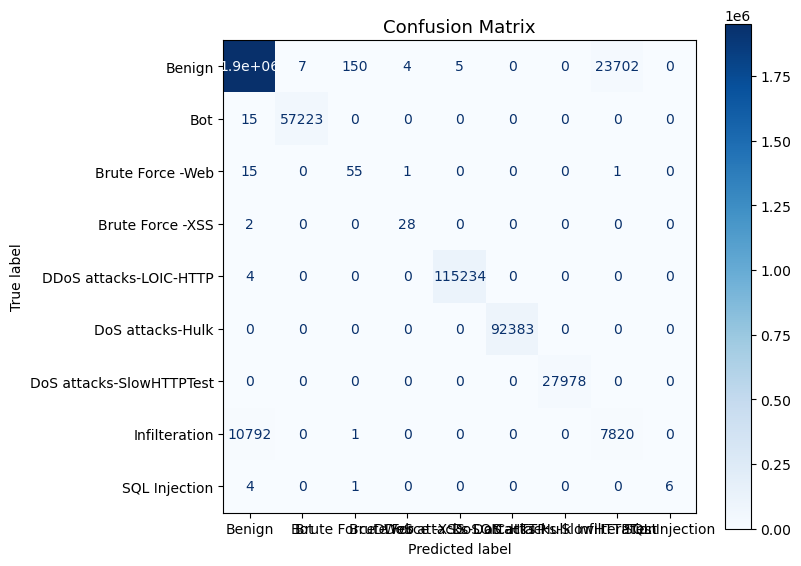

ROC AUC — ONE VS REST


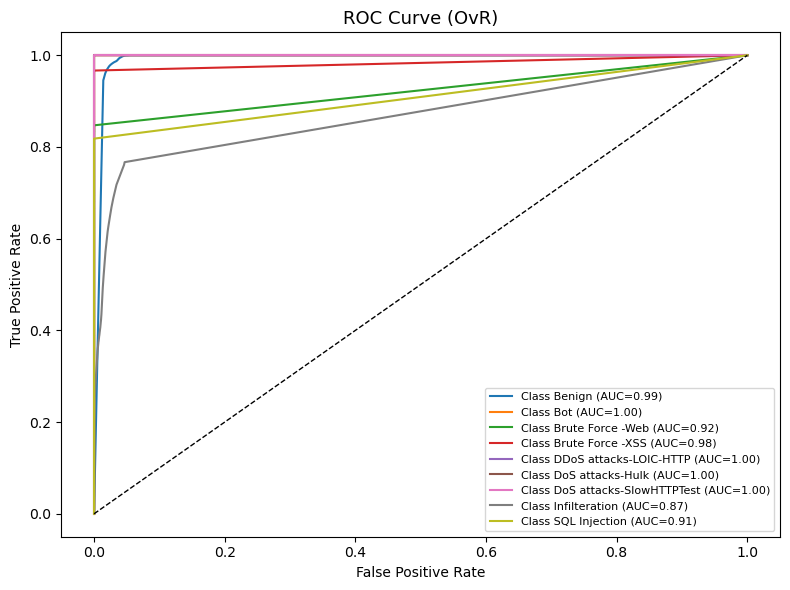

  Macro AUC : 0.9642
  Micro AUC : 0.9988
  Class Benign  : 0.9920
  Class Bot  : 1.0000
  Class Brute Force -Web  : 0.9236
  Class Brute Force -XSS  : 0.9833
  Class DDoS attacks-LOIC-HTTP  : 1.0000
  Class DoS attacks-Hulk  : 1.0000
  Class DoS attacks-SlowHTTPTest  : 1.0000
  Class Infilteration  : 0.8694
  Class SQL Injection  : 0.9091
PRECISION-RECALL CURVE


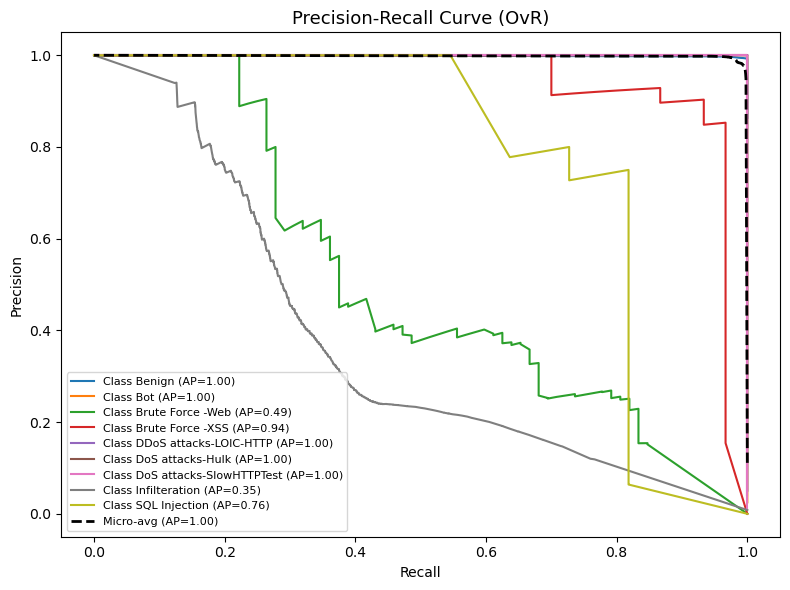

  Macro AP  : 0.8382
  Micro AP  : 0.9958
  Class Benign  : 0.9976
  Class Bot  : 1.0000
  Class Brute Force -Web  : 0.4943
  Class Brute Force -XSS  : 0.9425
  Class DDoS attacks-LOIC-HTTP  : 1.0000
  Class DoS attacks-Hulk  : 1.0000
  Class DoS attacks-SlowHTTPTest  : 1.0000
  Class Infilteration  : 0.3524
  Class SQL Injection  : 0.7571

SUMMARY
  Classes evaluated : ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'Infilteration', 'SQL Injection']
  Macro ROC AUC     : 0.9642
  Micro ROC AUC     : 0.9988
  Macro AP (PR)     : 0.8382
  Micro AP (PR)     : 0.9958


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.preprocessing import label_binarize
from sklearn.exceptions import UndefinedMetricWarning
import warnings

# ── Setup ──────────────────────────────────────────────────────────────────────
all_classes = model_weighted.classes_
present_idx = [np.where(all_classes == cls)[0][0] for cls in present_classes]
present_classes = sorted(set(y_test))
present_idx = [np.where(all_classes == cls)[0][0] for cls in present_classes]
n_present       = len(present_classes)
y_test_bin      = label_binarize(y_test, classes=present_classes)
y_probs_f       = y_probs[:, present_idx]   # align prob columns
y_pred          = model_weighted.predict(X_test)

print(f"Evaluating {n_present}/{n_classes} classes present in test set")
print(f"Missing classes: {set(n_classes) - set(present_classes)}\n")

# ── 1. Classification Report ───────────────────────────────────────────────────
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, zero_division=0))

# ── 2. Confusion Matrix ────────────────────────────────────────────────────────
print("=" * 55)
print("CONFUSION MATRIX")
print("=" * 55)
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=present_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. ROC AUC ────────────────────────────────────────────────────────────────
print("=" * 55)
print("ROC AUC — ONE VS REST")
print("=" * 55)
fig, ax = plt.subplots(figsize=(8, 6))
per_class_auc = {}

for idx, cls in enumerate(present_classes):
    if y_test_bin[:, idx].sum() == 0:
        print(f"  Class {cls}: skipped — not in test set")
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UndefinedMetricWarning)
        fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_probs_f[:, idx])
        auc_score    = roc_auc_score(y_test_bin[:, idx], y_probs_f[:, idx])
        per_class_auc[cls] = auc_score
        ax.plot(fpr, tpr, label=f"Class {cls} (AUC={auc_score:.2f})")

# Micro average
micro_auc = roc_auc_score(y_test_bin, y_probs_f, average='micro', multi_class='ovr')
macro_auc = np.mean(list(per_class_auc.values()))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (OvR)", fontsize=13)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"  Macro AUC : {macro_auc:.4f}")
print(f"  Micro AUC : {micro_auc:.4f}")
for cls, auc in per_class_auc.items():
    print(f"  Class {cls}  : {auc:.4f}")

# ── 4. Precision-Recall Curve ─────────────────────────────────────────────────
print("=" * 55)
print("PRECISION-RECALL CURVE")
print("=" * 55)
fig, ax = plt.subplots(figsize=(8, 6))
per_class_ap = {}

for idx, cls in enumerate(present_classes):
    if y_test_bin[:, idx].sum() == 0:
        print(f"  Class {cls}: skipped — not in test set")
        continue
    prec, rec, _ = precision_recall_curve(y_test_bin[:, idx], y_probs_f[:, idx])
    ap = average_precision_score(y_test_bin[:, idx], y_probs_f[:, idx])
    per_class_ap[cls] = ap
    ax.plot(rec, prec, label=f"Class {cls} (AP={ap:.2f})")

# Micro average
prec_micro, rec_micro, _ = precision_recall_curve(
    y_test_bin.ravel(), y_probs_f.ravel()
)
micro_ap = average_precision_score(y_test_bin, y_probs_f, average='micro')
macro_ap = average_precision_score(y_test_bin, y_probs_f, average='macro')

ax.plot(rec_micro, prec_micro, 'k--', linewidth=2,
        label=f"Micro-avg (AP={micro_ap:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (OvR)", fontsize=13)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"  Macro AP  : {macro_ap:.4f}")
print(f"  Micro AP  : {micro_ap:.4f}")
for cls, ap in per_class_ap.items():
    print(f"  Class {cls}  : {ap:.4f}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  Classes evaluated : {present_classes}")
print(f"  Macro ROC AUC     : {macro_auc:.4f}")
print(f"  Micro ROC AUC     : {micro_auc:.4f}")
print(f"  Macro AP (PR)     : {macro_ap:.4f}")
print(f"  Micro AP (PR)     : {micro_ap:.4f}")

In [24]:
#XgBoost
!pip install optuna
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import optuna

le = LabelEncoder()
y_train_label = le.fit_transform(y_train)
y_test_label = le.transform(y_test)
def classifier(trial):
    params = {
      'objective': 'binary:logistic',
      'max_depth': trial.suggest_int('max_depth', 8, 32),
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'min_child_weight': 200,
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
      'random_state': 42
      }
    model_weighted = XGBClassifier(**params)
    model_weighted.fit(X_train, y_train_label)
    preds = model_weighted.predict(X_test)
    score = f1_score(y_test_label, preds, average='macro')
    return score
study = optuna.create_study(direction='maximize')
study.optimize(classifier, n_trials=30)

print("Number of finished trials: ", len(study.trials))
print("Best trial value (F1): ", study.best_value)
print("Best parameters: ", study.best_params)

# 4. Train final model with best params
best_model = XGBClassifier(**study.best_params)
best_model.fit(X_train, y_train_label)
y_xgb_pred = best_model.predict(X_test)
print (y_xgb_pred)
"""
y_probs = best_model.predict_proba(X_test)[:, 1]

threshold = 0.95

y_pred_custom = (y_probs >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

best_model_roc_auc_score = roc_auc_score(y_test, y_pred_custom)
#vanilla xgboost
model_weighted = XGBClassifier(random_state=42)
model_weighted.fit(X_train, y_train)
y_probs = model_weighted.predict_proba(X_test)[:, 1]

threshold = 0.95

y_pred_custom = (y_probs >= threshold).astype(int)
base_model_roc_auc_score = roc_auc_score(y_test, y_pred_custom)

print(f"Baseline AUC:  {base_model_roc_auc_score:.4f}")
print(f"Optimized AUC: {best_model_roc_auc_score:.4f}")
print(f"Improvement:   {best_model_roc_auc_score - base_model_roc_auc_score:.4f}")
"""

[I 2026-03-28 17:55:28,271] A new study created in memory with name: no-name-610ae34d-cbbf-4e6b-a61d-54811212398f
[I 2026-03-28 18:39:15,013] Trial 0 finished with value: 0.6651197945707236 and parameters: {'max_depth': 13, 'n_estimators': 727, 'learning_rate': 0.2366722999405698}. Best is trial 0 with value: 0.6651197945707236.
[I 2026-03-28 19:36:38,818] Trial 1 finished with value: 0.6569990963596717 and parameters: {'max_depth': 25, 'n_estimators': 862, 'learning_rate': 0.2576157324410424}. Best is trial 0 with value: 0.6651197945707236.
[I 2026-03-28 20:03:41,219] Trial 2 finished with value: 0.6424836424218524 and parameters: {'max_depth': 10, 'n_estimators': 450, 'learning_rate': 0.16073510278102943}. Best is trial 0 with value: 0.6651197945707236.
[I 2026-03-28 20:15:49,011] Trial 3 finished with value: 0.5999772733575911 and parameters: {'max_depth': 14, 'n_estimators': 185, 'learning_rate': 0.11474824656051621}. Best is trial 0 with value: 0.6651197945707236.
[I 2026-03-28 20

Number of finished trials:  30
Best trial value (F1):  0.6679398353666874
Best parameters:  {'max_depth': 10, 'n_estimators': 370, 'learning_rate': 0.25999618148927833}
[0 0 4 ... 0 0 0]


'\ny_probs = best_model.predict_proba(X_test)[:, 1]\n\nthreshold = 0.95\n\ny_pred_custom = (y_probs >= threshold).astype(int)\nprint(classification_report(y_test, y_pred_custom))\n\nbest_model_roc_auc_score = roc_auc_score(y_test, y_pred_custom)\n#vanilla xgboost\nmodel_weighted = XGBClassifier(random_state=42)\nmodel_weighted.fit(X_train, y_train)\ny_probs = model_weighted.predict_proba(X_test)[:, 1]\n\nthreshold = 0.95\n\ny_pred_custom = (y_probs >= threshold).astype(int)\nbase_model_roc_auc_score = roc_auc_score(y_test, y_pred_custom)\n\nprint(f"Baseline AUC:  {base_model_roc_auc_score:.4f}")\nprint(f"Optimized AUC: {best_model_roc_auc_score:.4f}")\nprint(f"Improvement:   {best_model_roc_auc_score - base_model_roc_auc_score:.4f}")\n'

              precision    recall  f1-score   support

           0       0.99      1.00      1.00   1973552
           1       1.00      1.00      1.00     57238
           2       0.76      0.49      0.59        72
           3       0.82      0.93      0.88        30
           4       1.00      1.00      1.00    115238
           5       1.00      1.00      1.00     92383
           6       1.00      1.00      1.00     27978
           7       0.85      0.27      0.41     18613
           8       0.67      0.73      0.70        11

    accuracy                           0.99   2285115
   macro avg       0.90      0.82      0.84   2285115
weighted avg       0.99      0.99      0.99   2285115

ROC AUC (macro, OvR): 0.9936
Evaluating [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]/[0 1 2 3 4 5 6 7 8] classes present in test set
Missing classes: set()

CLASSIFICATION REPORT
              precision    recall  f1-score

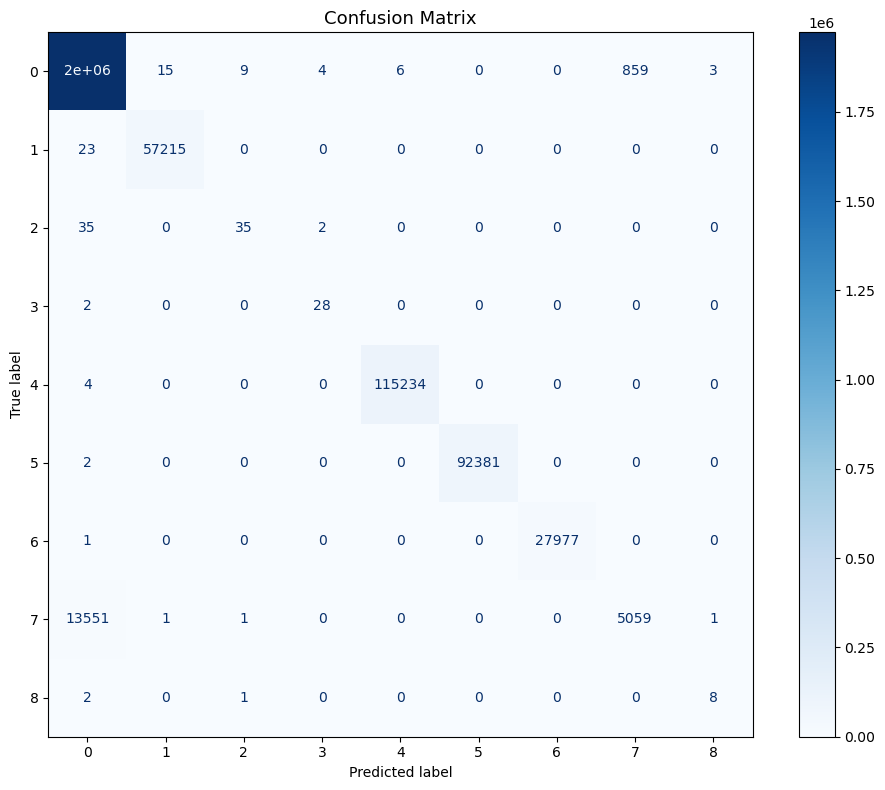

ROC AUC — ONE VS REST


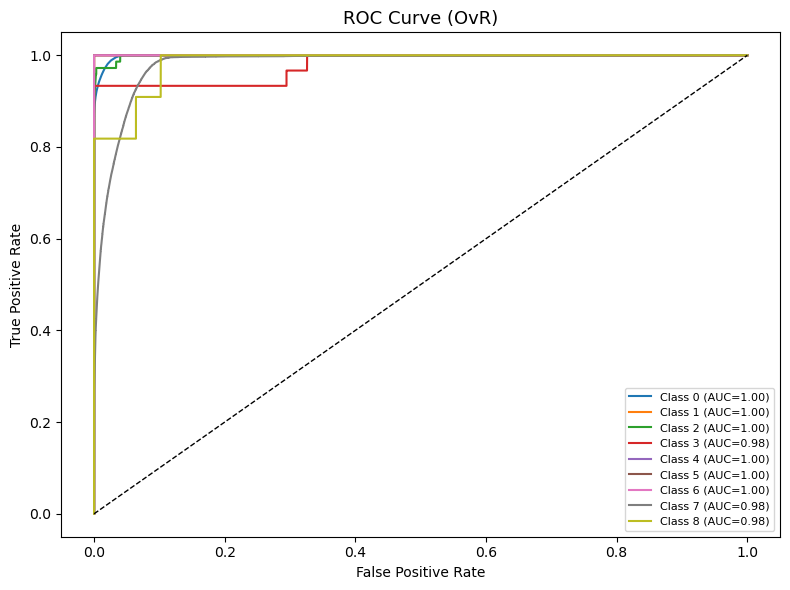

  Macro AUC : 0.9936
  Micro AUC : 0.9999
  Class 0  : 0.9986
  Class 1  : 1.0000
  Class 2  : 0.9988
  Class 3  : 0.9793
  Class 4  : 1.0000
  Class 5  : 1.0000
  Class 6  : 1.0000
  Class 7  : 0.9807
  Class 8  : 0.9849
PRECISION-RECALL CURVE


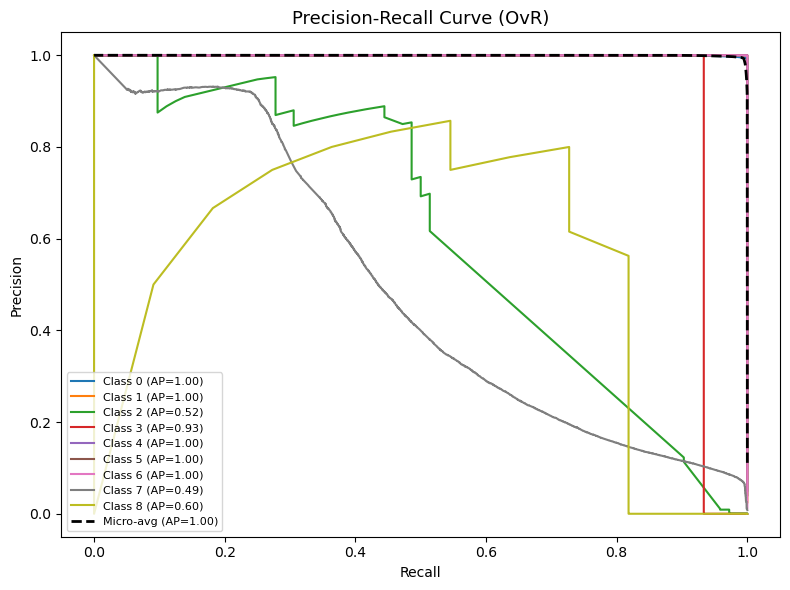

  Macro AP  : 0.8369
  Micro AP  : 0.9995
  Class 0  : 0.9998
  Class 1  : 0.9999
  Class 2  : 0.5159
  Class 3  : 0.9333
  Class 4  : 1.0000
  Class 5  : 1.0000
  Class 6  : 1.0000
  Class 7  : 0.4883
  Class 8  : 0.5952

SUMMARY
  Classes evaluated : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Macro ROC AUC     : 0.9936
  Micro ROC AUC     : 0.9999
  Macro AP (PR)     : 0.8369
  Micro AP (PR)     : 0.9995


In [31]:
print(classification_report(y_test_label, y_xgb_pred))
y_probs = best_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test_label, y_probs, multi_class='ovr', average='macro')
print(f"ROC AUC (macro, OvR): {roc_auc:.4f}")

# ── Setup ──────────────────────────────────────────────────────────────────────
all_classes = best_model.classes_
n_classes = len(all_classes)
present_classes = sorted(set(y_test_label))
present_idx = [np.where(all_classes == cls)[0][0] for cls in present_classes]
n_present       = len(present_classes)
y_test_bin      = label_binarize(y_test_label, classes=present_classes)
y_probs_f       = y_probs[:, present_idx]   # align prob columns
y_pred          = y_xgb_pred

print(f"Evaluating {present_classes}/{all_classes} classes present in test set")
print(f"Missing classes: {set(all_classes) - set(present_classes)}\n")

# ── 1. Classification Report ───────────────────────────────────────────────────
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test_label, y_pred, zero_division=0))

# ── 2. Confusion Matrix ────────────────────────────────────────────────────────
print("=" * 55)
print("CONFUSION MATRIX")
print("=" * 55)
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_label, y_pred, labels=present_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. ROC AUC ────────────────────────────────────────────────────────────────
print("=" * 55)
print("ROC AUC — ONE VS REST")
print("=" * 55)
fig, ax = plt.subplots(figsize=(8, 6))
per_class_auc = {}

for idx, cls in enumerate(present_classes):
    if y_test_bin[:, idx].sum() == 0:
        print(f"  Class {cls}: skipped — not in test set")
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UndefinedMetricWarning)
        fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_probs_f[:, idx])
        auc_score    = roc_auc_score(y_test_bin[:, idx], y_probs_f[:, idx])
        per_class_auc[cls] = auc_score
        ax.plot(fpr, tpr, label=f"Class {cls} (AUC={auc_score:.2f})")

# Micro average
micro_auc = roc_auc_score(y_test_bin, y_probs_f, average='micro', multi_class='ovr')
macro_auc = np.mean(list(per_class_auc.values()))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (OvR)", fontsize=13)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"  Macro AUC : {macro_auc:.4f}")
print(f"  Micro AUC : {micro_auc:.4f}")
for cls, auc in per_class_auc.items():
    print(f"  Class {cls}  : {auc:.4f}")

# ── 4. Precision-Recall Curve ─────────────────────────────────────────────────
print("=" * 55)
print("PRECISION-RECALL CURVE")
print("=" * 55)
fig, ax = plt.subplots(figsize=(8, 6))
per_class_ap = {}

for idx, cls in enumerate(present_classes):
    if y_test_bin[:, idx].sum() == 0:
        print(f"  Class {cls}: skipped — not in test set")
        continue
    prec, rec, _ = precision_recall_curve(y_test_bin[:, idx], y_probs_f[:, idx])
    ap = average_precision_score(y_test_bin[:, idx], y_probs_f[:, idx])
    per_class_ap[cls] = ap
    ax.plot(rec, prec, label=f"Class {cls} (AP={ap:.2f})")

# Micro average
prec_micro, rec_micro, _ = precision_recall_curve(
    y_test_bin.ravel(), y_probs_f.ravel()
)
micro_ap = average_precision_score(y_test_bin, y_probs_f, average='micro')
macro_ap = average_precision_score(y_test_bin, y_probs_f, average='macro')

ax.plot(rec_micro, prec_micro, 'k--', linewidth=2,
        label=f"Micro-avg (AP={micro_ap:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (OvR)", fontsize=13)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"  Macro AP  : {macro_ap:.4f}")
print(f"  Micro AP  : {micro_ap:.4f}")
for cls, ap in per_class_ap.items():
    print(f"  Class {cls}  : {ap:.4f}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"  Classes evaluated : {present_classes}")
print(f"  Macro ROC AUC     : {macro_auc:.4f}")
print(f"  Micro ROC AUC     : {micro_auc:.4f}")
print(f"  Macro AP (PR)     : {macro_ap:.4f}")
print(f"  Micro AP (PR)     : {micro_ap:.4f}")

In [ ]:
#shap tree explainer
!pip install shap
import shap

# Initialize the Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)
#shap.summary_plot(shap_values, X_test, plot_type="bar")
class_names = le.classes_  # original string labels

for i in range(n_present):
    print(f"--- SHAP Summary: {class_names[i]} ---")
    shap.summary_plot(
        shap_values.values[:, :, i],
        X_test,
        plot_type="bar",
        show=True
    )

def safe_idx(condition):
    result = np.where(condition)[0]
    if len(result) == 0:
        return None
    return result[0]
tp_idx = safe_idx((y_test_label != 0) & (y_xgb_pred == y_test_label))
fp_idx = safe_idx((y_test_label == 0) & (y_xgb_pred != 0))
tn_idx = safe_idx((y_test_label == 0) & (y_xgb_pred == 0))
ic_idx = safe_idx((y_test_label != 0) & (y_xgb_pred != y_test_label))

for idx, label in zip([tp_idx, fp_idx, tn_idx, ic_idx],
                      ["True Positive", "False Positive", "True Negative", "Incorrect Classification"]):
    if idx is None:
        print(f"--- No sample found for: {label} ---")
        continue
    print(f"--- Waterfall Plot for: {label} (Row {idx}) ---")
    predicted_class = y_xgb_pred[idx]
    shap.plots.waterfall(shap_values[idx, :, predicted_class])

This Model Card summarizes the XGBoost Alert Classifier optimized via Optuna. It serves as a transparency document for stakeholders and engineers.
------------------------------
1. Model Card: XGBoost Alert Classifier v1.01. Model Details

* Developer: Manish Jha
* Model Type: Gradient Boosted Decision Trees (XGBoost)
* Optimization: Bayesian Optimization via Optuna (30-trial search).
* Key Hyperparameters: max_depth, learning_rate, n_estimators.
* Date: March 2026

2. Training Data

* Dataset: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv.
* Size: 45149 samples with 78 features.
* Preprocessing: Standardized numerical features; Adjusted port numbers below 1. removed average (mean,min, max, std) features.
* Splitting: 80% Training / 20% Testing (Stratified to maintain class balance).

3. Performance Metrics

* AUC-ROC: 0.99 (Higher is better; measures ability to distinguish classes).
* Precision/Recall: Optimized for Precission using a custom probability threshold of 0.95 to minimize False Positives.
* Global Importance: Based on SHAP TreeExplainer, the top contributing features are `Avg Fwd Segment Size` and `Total Length of packets`.

4. Known Failure Modes

* Threshold Sensitivity: At a default 0.5 threshold, the model may flag "borderline" safe activities as threats.
* Feature Dominance: SHAP analysis shows heavy reliance on `Avg Fwd Segment Size`; if this data stream is corrupted or missing, model reliability drops significantly.
* Adversarial Evasion: The model may fail against "Zero-Day" attacks specifically designed to mimic the statistical profile of "Normal" traffic.

5. Limitations

* Temporal (Time): The model is trained on a "snapshot" of threats. It suffers from Data Drift and requires retraining every 3 months to stay relevant against evolving attack patterns.
* Demographic/Scope: This model is calibrated for Internal Corporate Networks and may produce inaccurate results if applied to Public Cloud/IoT environments without fine-tuning.
* Hardware: Optimized for CPU-based inference; latency may increase under high-throughput "burst" traffic.


Shap O/P:
Summary-

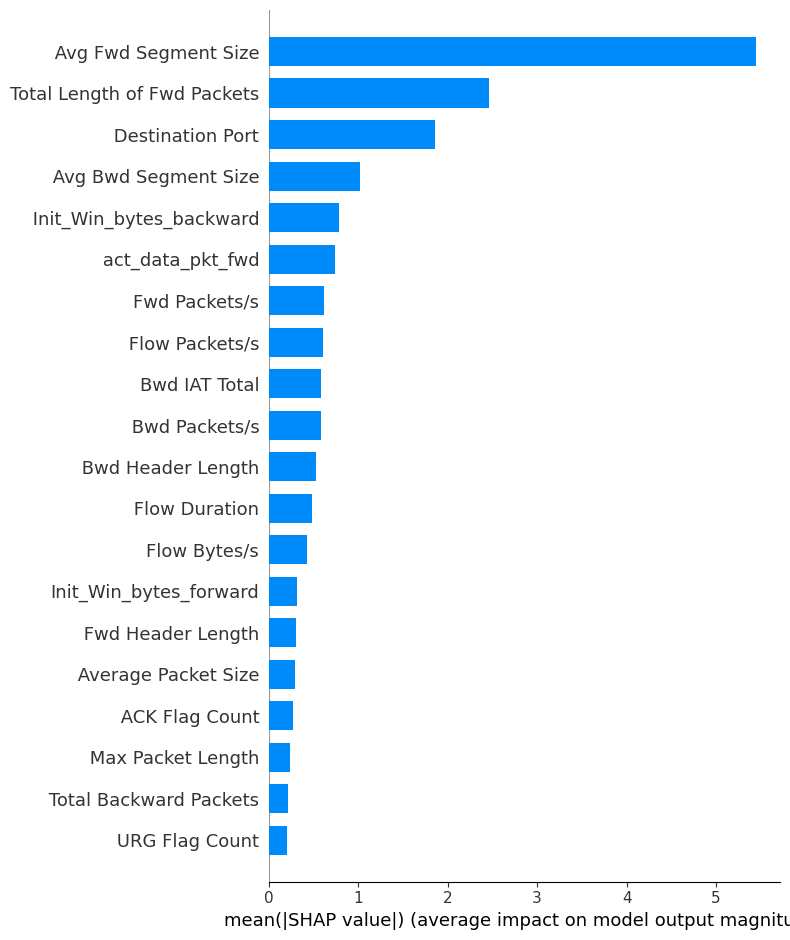

TP plot:
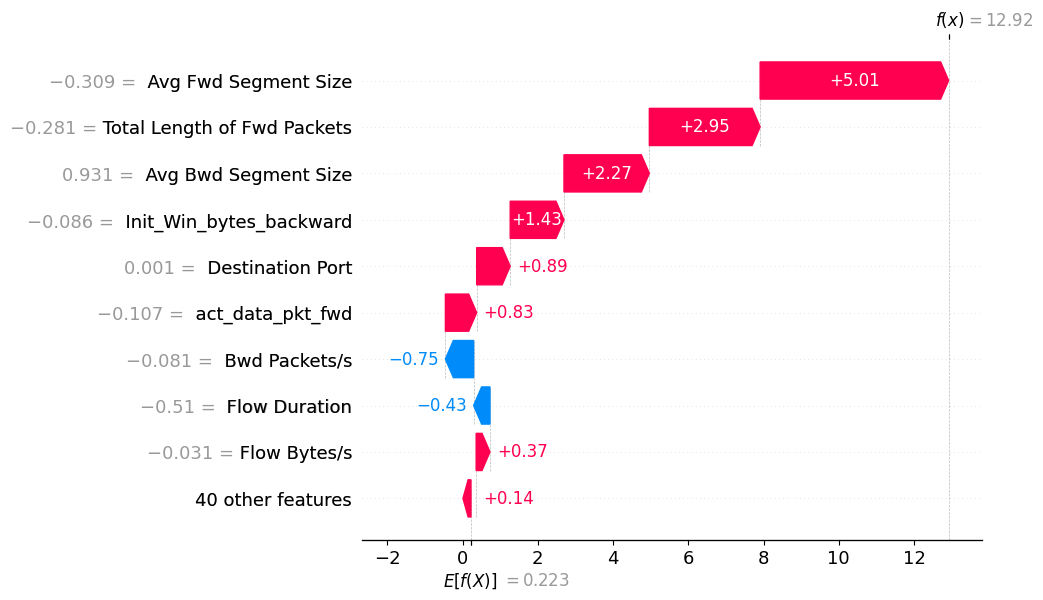

TN Plot:
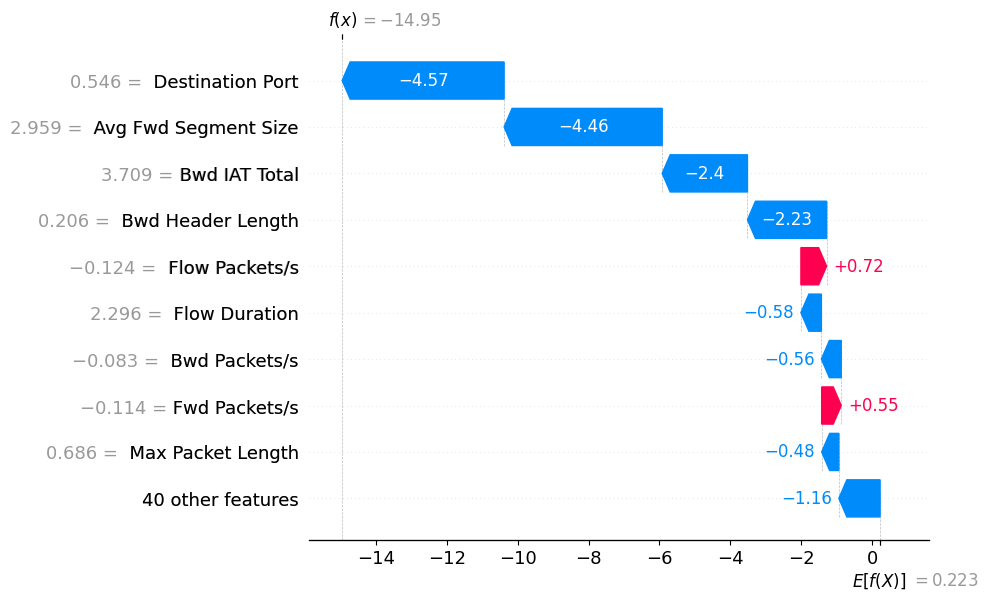


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "chethuhn/network-intrusion-dataset",
  file_path
)

print (df.columns)
print("First 5 records:", df.head())